In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example Data: Number of errors per model
data = {
    "Model": ["Model A", "Model B", "Model C"] * 3,
    "Minor": [120, 90, 110] * 3,
    "Major": [60, 80, 50] * 3,
    "Critical": [10, 20, 30] * 3
}


In [39]:
score_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/scores"
score_files = {
    corpus: f"{score_dir}/scores_{corpus}.csv" for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb"]
}

In [54]:
dfs = {corpus: pd.read_csv(score_files[corpus]) for corpus in score_files}

In [77]:
df = dfs["footweets"][["model", "minor", "major", "critical", "total"]].copy()
df["model"] = df["model"].str.split("/").str[1]
# df["minor"] = df["minor"] / df["total"] * 100
# df["major"] = df["major"] / df["total"] * 100
# df["critical"] = df["critical"] / df["total"] * 100
df = df.drop("total", axis=1)
df

,model,minor,major,critical
0,nllb-200-3.3B,8361,299,65
1,Llama-3.1-8B-Instruct,10032,375,169
2,Llama-3.1-8B-Instruct,9456,370,74
3,Llama-3.1-8B-Instruct,9558,343,62
4,gemma-2-9b-it,9203,231,77
5,gemma-2-9b-it,8837,239,39
6,gemma-2-9b-it,9124,216,30


Stacked bar chart

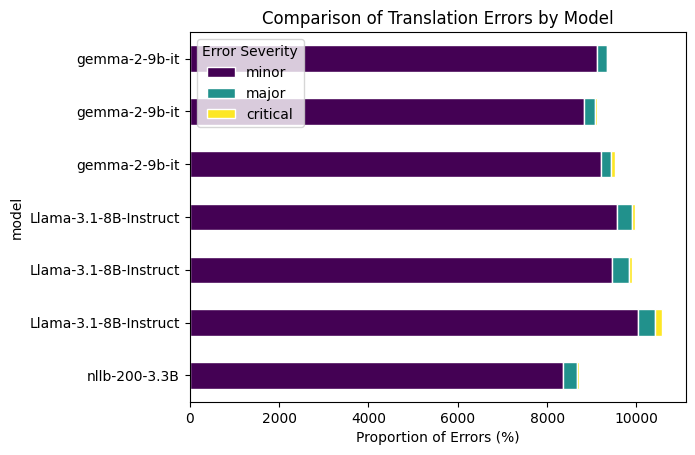

In [78]:

# Plot
df.set_index("model").plot(kind="barh", stacked=True, colormap="viridis", edgecolor="white")
plt.xlabel("Proportion of Errors (%)")
plt.title("Comparison of Translation Errors by Model")
plt.legend(title="Error Severity")
plt.show()

Heatmap

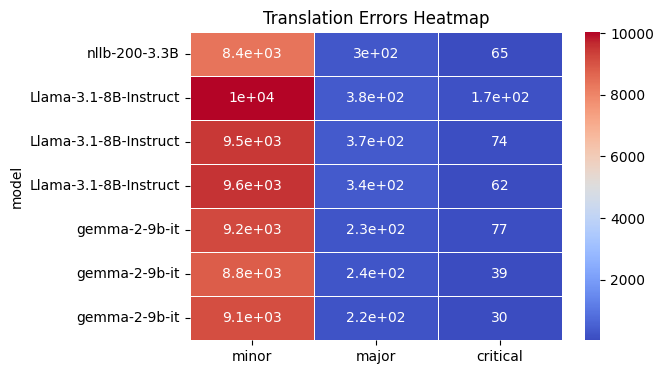

In [79]:
# df = pd.DataFrame(data)
plt.figure(figsize=(6, 4))
sns.heatmap(df.set_index("model"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Translation Errors Heatmap")
plt.show()
